# 01. Exploratory Data Analysis: CLINC150

Анализ датасета CLINC150 для задачи OOS-детекции.

**Prerequisite:** запустить `python scripts/prepare_data.py`

## 1. Setup

In [ ]:
import sys
sys.path.insert(0, "../../..")
sys.path.insert(0, "..")

from src.data_utils import (
    load_split,
    load_fewshot,
    load_meta,
    get_intent_names
)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

# Data source
SOURCE = "deeppavlov"  # or "standard"

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## 2. Dataset Overview

In [ ]:
# Load metadata
meta = load_meta(SOURCE)
print(f"Source: {SOURCE}")
print(f"OOS label in standard format: {meta.get('oos_label', -1)}")
print(f"Number of in-scope intents: {meta['n_intents']}")

In [ ]:
# Load all splits
train = load_split(SOURCE, "train")
val = load_split(SOURCE, "validation")
test = load_split(SOURCE, "test")

# Create overview table
def split_stats(data, name):
    labels = data["labels"]
    n_oos = sum(1 for l in labels if l == -1)
    n_inscope = len(labels) - n_oos
    oos_pct = 100 * n_oos / len(labels)
    return {
        "Split": name,
        "In-scope": n_inscope,
        "OOS": n_oos,
        "Total": len(labels),
        "OOS%": f"{oos_pct:.1f}%"
    }

overview = pd.DataFrame([
    split_stats(train, "train"),
    split_stats(val, "validation"),
    split_stats(test, "test")
])
print("\nDataset Overview:")
display(overview)

In [ ]:
print("\nNote: OOS% in test (~18%) represents a realistic guardrail scenario.")

## 3. Intent Distribution

In [ ]:
# Count examples per intent in train (excluding OOS)
train_inscope_labels = [l for l in train["labels"] if l != -1]
intent_counts = Counter(train_inscope_labels)

print(f"Number of unique intents in train: {len(intent_counts)}")
print(f"Examples per intent: min={min(intent_counts.values())}, "
      f"max={max(intent_counts.values())}, "
      f"mean={np.mean(list(intent_counts.values())):.1f}")

In [ ]:
# Visualize intent distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = list(intent_counts.values())

# Left: Histogram (will show single bar for balanced dataset)
axes[0].hist(counts, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.1f}')
axes[0].set_xlabel('Examples per Intent')
axes[0].set_ylabel('Number of Intents')
axes[0].set_title('Distribution of Examples per Intent')
axes[0].legend()

# Right: Bar chart of top/bottom intents (or sample if all equal)
sorted_intents = sorted(intent_counts.items(), key=lambda x: x[1])
intent_names = get_intent_names(SOURCE)

# Show first 10 intents as sample
sample_intents = sorted_intents[:10]
names = [intent_names.get(i, f"intent_{i}")[:20] for i, _ in sample_intents]
values = [c for _, c in sample_intents]

axes[1].barh(names, values, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Examples')
axes[1].set_title('Sample: First 10 Intents (all should be ~100)')
axes[1].set_xlim(0, max(values) * 1.2)

plt.tight_layout()
plt.show()

is_balanced = max(counts) - min(counts) <= 10
print(f"\nDataset is {'BALANCED' if is_balanced else 'IMBALANCED'}: "
      f"range = {max(counts) - min(counts)}")
print(f"This is expected for CLINC150 — exactly 100 examples per intent.")

## 4. OOS Analysis

In [ ]:
# Sample OOS and in-scope examples from test
np.random.seed(42)

test_texts = test["texts"]
test_labels = test["labels"]

oos_indices = [i for i, l in enumerate(test_labels) if l == -1]
inscope_indices = [i for i, l in enumerate(test_labels) if l != -1]

sample_oos = np.random.choice(oos_indices, size=10, replace=False)
sample_inscope = np.random.choice(inscope_indices, size=10, replace=False)

print("10 Random OOS Examples (test):")
print("-" * 60)
for i in sample_oos:
    print(f"  {test_texts[i]}")

print("\n10 Random In-scope Examples (test):")
print("-" * 60)
intent_names = get_intent_names(SOURCE)
for i in sample_inscope:
    label = test_labels[i]
    intent_name = intent_names.get(label, "unknown")
    print(f"  [{intent_name}] {test_texts[i]}")

In [19]:
print("\nObservation: OOS examples are often semantically similar to in-scope,")
print("making them challenging to detect. This is the 'hard OOS' scenario.")


Observation: OOS examples are often semantically similar to in-scope,
making them challenging to detect. This is the 'hard OOS' scenario.


## 5. Utterance Length Distribution

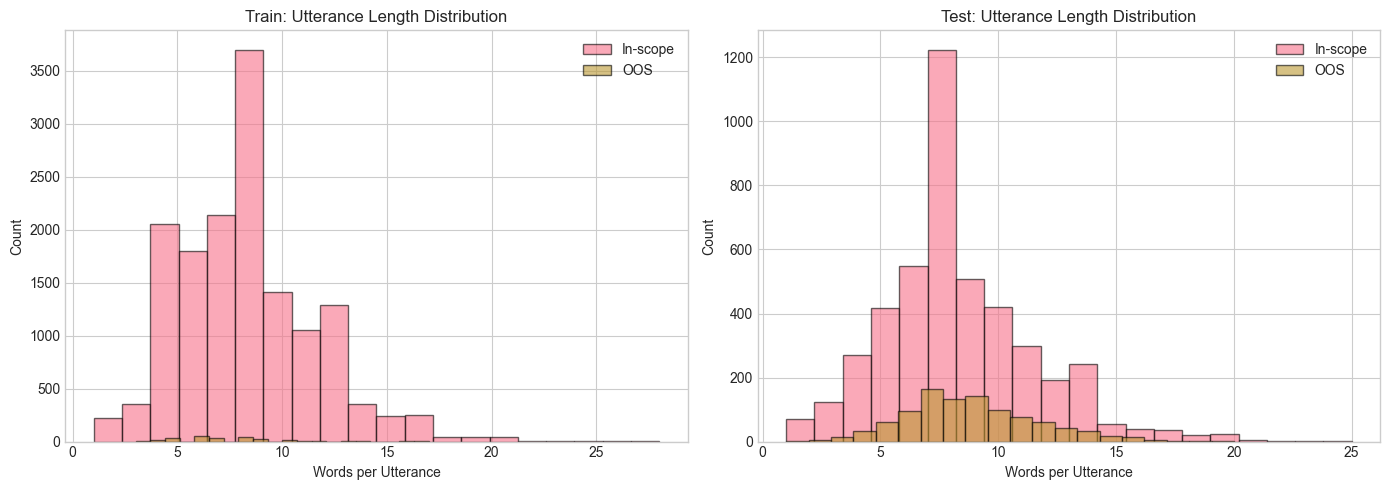


Train in-scope: mean=8.3 words
Train OOS: mean=7.3 words
Test in-scope: mean=8.2 words
Test OOS: mean=8.7 words


In [20]:
def word_count(text):
    return len(text.split())

# Train
train_oos_lengths = [word_count(t) for t, l in zip(train["texts"], train["labels"]) if l == -1]
train_inscope_lengths = [word_count(t) for t, l in zip(train["texts"], train["labels"]) if l != -1]

# Test
test_oos_lengths = [word_count(t) for t, l in zip(test["texts"], test["labels"]) if l == -1]
test_inscope_lengths = [word_count(t) for t, l in zip(test["texts"], test["labels"]) if l != -1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
axes[0].hist(train_inscope_lengths, bins=20, alpha=0.6, label='In-scope', edgecolor='black')
axes[0].hist(train_oos_lengths, bins=20, alpha=0.6, label='OOS', edgecolor='black')
axes[0].set_xlabel('Words per Utterance')
axes[0].set_ylabel('Count')
axes[0].set_title('Train: Utterance Length Distribution')
axes[0].legend()

# Test
axes[1].hist(test_inscope_lengths, bins=20, alpha=0.6, label='In-scope', edgecolor='black')
axes[1].hist(test_oos_lengths, bins=20, alpha=0.6, label='OOS', edgecolor='black')
axes[1].set_xlabel('Words per Utterance')
axes[1].set_ylabel('Count')
axes[1].set_title('Test: Utterance Length Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nTrain in-scope: mean={np.mean(train_inscope_lengths):.1f} words")
print(f"Train OOS: mean={np.mean(train_oos_lengths):.1f} words")
print(f"Test in-scope: mean={np.mean(test_inscope_lengths):.1f} words")
print(f"Test OOS: mean={np.mean(test_oos_lengths):.1f} words")

## 6. Few-shot Splits

In [ ]:
meta = load_meta(SOURCE)
fewshot_stats = []
for n in [10, 20, 50]:
    fs = load_fewshot(SOURCE, n, 42)
    n_oos = sum(1 for l in fs["labels"] if l == -1)
    n_inscope = len(fs["labels"]) - n_oos
    oos_pct = 100 * n_oos / len(fs["labels"])
    fewshot_stats.append({
        "n_shots": n,
        "In-scope": n_inscope,
        "OOS": n_oos,
        "Total": len(fs["labels"]),
        "OOS%": f"{oos_pct:.1f}%"
    })

fewshot_df = pd.DataFrame(fewshot_stats)
print("Few-shot Splits (seed=42):")
display(fewshot_df)

print(f"\nOOS ratio target: {meta['fewshot']['oos_ratio']} (= {int(meta['fewshot']['oos_ratio'] * 100)}%)")
print(f"Seeds used: {meta['fewshot']['seeds']}")

## 7. Data Quality Checks

In [22]:
issues = []

# Check 1: Duplicates within train
train_texts_set = set(train["texts"])
n_duplicates = len(train["texts"]) - len(train_texts_set)
if n_duplicates > 0:
    issues.append(f"Found {n_duplicates} duplicate texts in train")
print(f"Duplicates in train: {n_duplicates}")

# Check 2: Train-test overlap
test_texts_set = set(test["texts"])
overlap = train_texts_set & test_texts_set
if len(overlap) > 0:
    issues.append(f"Found {len(overlap)} overlapping texts between train and test")
print(f"Train-test text overlap: {len(overlap)}")

# Check 3: OOS vs in-scope overlap (same text with different labels)
train_oos_texts = set(t for t, l in zip(train["texts"], train["labels"]) if l == -1)
train_inscope_texts = set(t for t, l in zip(train["texts"], train["labels"]) if l != -1)
oos_inscope_overlap = train_oos_texts & train_inscope_texts
if len(oos_inscope_overlap) > 0:
    issues.append(f"Found {len(oos_inscope_overlap)} texts labeled both OOS and in-scope")
print(f"OOS vs in-scope overlap: {len(oos_inscope_overlap)}")

# Check 4: All 150 intents present in train
unique_inscope_labels = set(l for l in train["labels"] if l != -1)
n_missing_intents = 150 - len(unique_inscope_labels)
if n_missing_intents > 0:
    issues.append(f"Missing {n_missing_intents} intents in train")
print(f"Unique in-scope intents in train: {len(unique_inscope_labels)} (expected: 150)")

print("\n" + "=" * 40)
if issues:
    print("Issues found:")
    for issue in issues:
        print(f"  - {issue}")
else:
    print("All checks passed")

Duplicates in train: 0
Train-test text overlap: 0
OOS vs in-scope overlap: 0
Unique in-scope intents in train: 150 (expected: 150)

All checks passed


## 8. Summary

In [23]:
test_oos_rate = sum(1 for l in test["labels"] if l == -1) / len(test["labels"])

print("CLINC150 Dataset Summary for OOS Detection")
print("=" * 50)
print(f"")
print(f"- 150 in-scope intent classes")
print(f"- OOS base rate in test: {test_oos_rate:.1%}")
print(f"- Train: {len(train['texts']):,} examples ({sum(1 for l in train['labels'] if l == -1)} OOS)")
print(f"- Test: {len(test['texts']):,} examples ({sum(1 for l in test['labels'] if l == -1):,} OOS)")
print(f"")
print(f"Key observations:")
print(f"- Intent distribution is balanced (~100 examples per intent)")
print(f"- OOS examples are semantically challenging (hard OOS)")
print(f"- Utterance lengths are similar for OOS and in-scope")
print(f"- No data leakage between train and test")
print(f"")
print(f"Ready for model experiments.")

CLINC150 Dataset Summary for OOS Detection

- 150 in-scope intent classes
- OOS base rate in test: 18.2%
- Train: 15,251 examples (251 OOS)
- Test: 5,498 examples (1,000 OOS)

Key observations:
- Intent distribution is balanced (~100 examples per intent)
- OOS examples are semantically challenging (hard OOS)
- Utterance lengths are similar for OOS and in-scope
- No data leakage between train and test

Ready for model experiments.
